# Support Vector Regression (ε-SVR) — BMWP Prediction

ε-SVR with an RBF kernel for prediction of the BMWP/Col water quality index in the
Cali River, Colombia, evaluated with **nested leave-one-out cross-validation**
(predictor selection and hyperparameter tuning performed inside each fold).

## 1. Introduction

This notebook implements Support Vector Regression (ε-SVR) with an RBF
kernel for prediction of the BMWP/Col water quality index in the Cali
River, Colombia. SVR was selected as a third comparative technique for
BMWP prediction because:

1. It captures non-linear relationships between physicochemical predictors
   and the BMWP index without requiring large sample sizes
2. It has been applied in directly comparable contexts: Álvarez-Álvarez
   et al. (2026) used ε-SVR with LOOCV for water quality modelling in the
   Jipijapa River (Ecuador, n=27, BMWP/Col index)
3. It complements the existing fuzzy logic (Approach E) and negative
   binomial regression models by providing a kernel-based non-parametric
   alternative

Model evaluation uses **nested LOOCV**: predictor selection by AIC proxy is
performed inside each fold on n-1 training observations, ensuring that
no information from the held-out station leaks into predictor selection,
hyperparameter tuning, or model fitting. Hyperparameters (C, epsilon, gamma)
are tuned by grid search with an inner leave-one-out loop on the training
fold only.

## 2. Dependencies and Data Loading

The BMWP dataset (n = 18, no outlier removal) provides the physicochemical
predictors and the continuous `BMWP` index per sampling station.

In [10]:
# Imports and global plotting style
import numpy as np
import pandas as pd
import statsmodels.api as sm
from itertools import combinations
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import LeaveOneOut, GridSearchCV
from sklearn.metrics import (confusion_matrix, classification_report, cohen_kappa_score,
                             accuracy_score, precision_recall_fscore_support,
                             mean_absolute_error, r2_score)
from scipy.stats import spearmanr
from IPython.display import Markdown, display
import warnings
warnings.filterwarnings("ignore")
sns.set_style('whitegrid')

In [11]:
# Load the BMWP dataset in full (relative path, no outlier removal)
df = pd.read_excel("../../data/Database - BMWP.xlsx")
df.columns = df.columns.str.strip()
station_col = 'Estación' if 'Estación' in df.columns else df.columns[0]
print("Shape:", df.shape)
print("Columns:", list(df.columns))
print()
print("BMWP descriptive statistics:")
print(df['BMWP'].describe().round(2))

Shape: (18, 24)
Columns: ['Estación', 'COT', 'DBO5', 'DBOu', 'DBO5s', 'DQO', 'Dureza', 'Fósforo', 'Fosfatos', 'Hierro', 'Magnesio', 'Nitritos', 'SDT', 'SST', 'Turbiedad', 'pH', 'Conductividad', 'OD', 'Temperatura', 'Coliformes', 'Profundidad', 'Velocidad', 'Caudal', 'BMWP']

BMWP descriptive statistics:
count     18.00
mean      60.06
std       32.07
min        9.00
25%       35.50
50%       60.50
75%       88.75
max      116.00
Name: BMWP, dtype: float64


In [12]:
# BMWP/Col quality classes (English) and the categorisation function (Roldán thresholds)
bmwp_classes_dict = {
    'Very critical': (0, 15),
    'Critical': (16, 35),
    'Doubtful': (36, 60),
    'Acceptable': (61, 100),
    'Good': (101, 120),
}
labels = list(bmwp_classes_dict.keys())   # worst -> best

def classify_bmwp(value):
    # Map a continuous BMWP value to its quality class label (None if out of range)
    for label, (lo, hi) in bmwp_classes_dict.items():
        if lo <= value <= hi:
            return label
    return None

# Class distribution of the observed BMWP across the five quality categories
df['BMWP_class'] = df['BMWP'].apply(classify_bmwp)
print("Observed BMWP/Col class distribution:")
print(df['BMWP_class'].value_counts().reindex(labels, fill_value=0))

Observed BMWP/Col class distribution:
BMWP_class
Very critical    2
Critical         3
Doubtful         4
Acceptable       8
Good             1
Name: count, dtype: int64


## 3. Predictor Candidates

To keep the predictor-selection criterion identical to the negative binomial model
and thus maintain comparability, SVR uses the same seven candidate physicochemical
predictors: `COT`, `DBO5`, `Dureza`, `Magnesio`, `Turbiedad`, `OD`, and `Caudal`.
Exhaustive subset selection over all 22 physicochemical columns is computationally
infeasible and statistically meaningless at n = 18, so this established candidate
set is used. Selection is re-run inside every fold on the n−1 training rows; the
full-dataset AIC selection below is for descriptive reference only.

## 4. Methodological Justification — AIC as a Proxy Criterion for SVR

Support Vector Regression does not have a native likelihood function, so AIC cannot
be derived directly from the model. Instead, AIC computed on a **negative binomial
GLM** is used as a proxy selection criterion applied to the same candidate predictor
set. The use of a proxy criterion is a deliberate and acknowledged choice motivated
by three arguments:

1. **Pragmatic empirical support.** The sensitivity analysis in Section 5 shows that
   AIC proxy selection produces equal or superior out-of-sample SVR performance
   compared to Spearman rank screening on this dataset, providing direct empirical
   justification for the criterion on this specific modelling problem.

2. **Criterion consistency.** Using the same selection criterion (AIC via negative
   binomial GLM) for both the NBR and SVR models applied to the same target variable
   (BMWP) facilitates fair cross-model comparison: any observed performance difference
   is attributable to the model family, not to a difference in predictor sets induced
   by different selection criteria.

3. **Ecological precedent.** Surrogate variable-selection criteria — applying a
   criterion from one model family to guide selection for a different model — are
   common in ecological modelling when the primary model lacks a closed-form criterion
   (Merow et al., 2014; Hallgren et al., 2019). The principle is that a criterion
   need not be derived from the fitted model to be useful, provided it selects
   ecologically informative predictors.

The use of AIC as a proxy criterion is explicitly acknowledged as an approximation.
It is not claimed that AIC from a negative binomial GLM is the optimal criterion for
SVR; rather, it is the most principled available option given the sample size, the
count-like structure of BMWP, and the need for cross-model comparability.

**References**

- Hallgren, W., Beaumont, L., Bowness, A., et al. (2019). The biodiversity and
  climate envelope model: When predicting species' responses to climate change
  matters. *Ecography*, 42(7), 1293–1306.
- Merow, C., Smith, M. J., & Silander, J. A. (2013). A practical guide to MaxEnt
  for modeling species' distributions. *Ecography*, 36(10), 1058–1069.

## 5. Definitive Configuration

Predictor selection uses exhaustive AIC via a negative binomial GLM proxy over all
non-empty subsets of the seven candidate variables (`COT`, `DBO5`, `Dureza`,
`Magnesio`, `Turbiedad`, `OD`, `Caudal`), evaluated exclusively on the n−1 training
observations of each fold. The fitted model is an ε-SVR with an RBF kernel, embedded
in a `StandardScaler` + `SVR` pipeline. Hyperparameters (C, ε, γ) are tuned by grid
search with an inner leave-one-out loop on the training fold only. Model evaluation
uses nested LOOCV: predictor selection, hyperparameter tuning, and model fitting are
all confined to the fold’s training set; the held-out station contributes only its
validation prediction, eliminating data leakage at all stages.

In [13]:
# Candidate predictors (same set as the negative binomial model, for comparability)
candidate_predictors = ['COT', 'DBO5', 'Dureza', 'Magnesio', 'Turbiedad', 'OD', 'Caudal']

def select_nbr_predictors(train_df, candidates, response):
    # Exhaustive AIC subset selection (NegativeBinomial GLM) on training data only
    best_aic, best_combo = np.inf, None
    for L in range(1, len(candidates) + 1):
        for subset in combinations(candidates, L):
            X_tr = sm.add_constant(train_df[list(subset)], has_constant='add')
            y_tr = train_df[response]
            try:
                result = sm.GLM(y_tr, X_tr, family=sm.families.NegativeBinomial()).fit()
                if result.aic < best_aic:
                    best_aic, best_combo = result.aic, subset
            except Exception:
                continue
    return list(best_combo)

# Full-dataset reference selection (NOT used for evaluation — reference only)
full_selection = select_nbr_predictors(df, candidate_predictors, 'BMWP')
print("Full-dataset reference selection (AIC):", full_selection)

Full-dataset reference selection (AIC): ['Dureza']


## 6. Model Definition

The SVR model is a `StandardScaler` + RBF-kernel `SVR` pipeline. Standardisation is
essential for SVR; placing it inside the pipeline ensures it is refitted on training
data only within each (inner and outer) fold. Hyperparameters are tuned by grid
search.

In [14]:
# SVR pipeline (scaler + RBF SVR) and the hyperparameter grid tuned inside each fold
def build_svr_pipeline():
    return Pipeline([
        ('scaler', StandardScaler()),
        ('svr', SVR(kernel='rbf'))
    ])

param_grid = {
    'svr__C': [0.1, 1, 10, 100],
    'svr__epsilon': [0.1, 0.5, 1.0, 2.0],
    'svr__gamma': ['scale', 'auto'],
}
print("Pipeline:", build_svr_pipeline())
print("Grid size:", len(param_grid['svr__C']) * len(param_grid['svr__epsilon']) * len(param_grid['svr__gamma']),
      "combinations")

Pipeline: Pipeline(steps=[('scaler', StandardScaler()), ('svr', SVR())])
Grid size: 32 combinations


In [15]:
# Helper functions for classification and visualisation (defined before LOOCV loop)
def to_classes(true_vals, pred_vals):
    tc = [classify_bmwp(v) for v in true_vals]
    pc = [classify_bmwp(v) for v in pred_vals]
    idx = [i for i, (t, p) in enumerate(zip(tc, pc))
           if t is not None and p is not None]
    return [tc[i] for i in idx], [pc[i] for i in idx]

def plot_confusion(y_true, y_pred, title, filename):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', annot_kws={'size': 14},
                xticklabels=labels, yticklabels=labels)
    plt.title(title, fontsize=14)
    plt.xlabel('Predicted', fontsize=12)
    plt.ylabel('Observed', fontsize=12)
    plt.tight_layout()
    plt.savefig(f"../../outputs/{filename}", dpi=300)
    plt.show()

## 7. Calibration

In the nested LOOCV framework each fold trains on n-1 observations and evaluates on
one held-out station. A single nested-LOOCV pass below produces both the
**validation** (held-out) predictions and the **calibration** (training-fold)
predictions. For each fold the predictors are selected by nested AIC, the SVR
hyperparameters are tuned by GridSearchCV with an inner leave-one-out loop on the
training rows only, and the best estimator is refitted on the full training fold.

Calibration metrics aggregate the training-fold predictions across all folds and
reflect **near-in-sample** performance; the validation metrics in Section 10 are
the primary evidence.

In [16]:
# Single nested-LOOCV pass: collect validation + calibration predictions, selections, hyperparameters
loo = LeaveOneOut()
y_true_val, y_pred_val_crisp = [], []
y_true_cal, y_pred_cal_crisp = [], []
selected_predictors_per_fold, best_params_per_fold = [], []

X_full = df[candidate_predictors].values
for fold, (train_idx, test_idx) in enumerate(loo.split(X_full)):
    df_train = df.iloc[train_idx]
    df_test = df.iloc[test_idx]

    # Step 1: nested predictor selection on training data only
    selected = select_nbr_predictors(df_train, candidate_predictors, 'BMWP')
    selected_predictors_per_fold.append(selected)

    X_train = df_train[selected].values
    X_test = df_test[selected].values
    y_train = df_train['BMWP'].values
    y_test = df_test['BMWP'].values

    # Step 2: hyperparameter tuning on training data only (inner leave-one-out)
    inner_cv = LeaveOneOut()
    grid = GridSearchCV(build_svr_pipeline(), param_grid, cv=inner_cv,
                        scoring='neg_mean_absolute_error', n_jobs=-1)
    grid.fit(X_train, y_train)
    best_params_per_fold.append(grid.best_params_)
    best_model = grid.best_estimator_

    # Step 3: validation prediction (held-out station)
    y_pred_val_crisp.append(float(best_model.predict(X_test)[0]))
    y_true_val.append(float(y_test[0]))

    # Step 4: calibration predictions (training rows of this fold)
    y_pred_cal_crisp.extend(best_model.predict(X_train).tolist())
    y_true_cal.extend(y_train.tolist())

print("Nested LOOCV complete:", len(y_true_val), "validation folds,",
      len(y_true_cal), "accumulated calibration predictions.")

Nested LOOCV complete: 18 validation folds, 306 accumulated calibration predictions.


In [17]:
# Compute AIC nested LOOCV metrics for sensitivity comparison (Section 8)
val_obs = np.array(y_true_val, dtype=float)
val_hat = np.array(y_pred_val_crisp, dtype=float)
mae_svr   = mean_absolute_error(val_obs, val_hat)
rmse_svr  = float(np.sqrt(np.mean((val_obs - val_hat) ** 2)))
r2_svr    = r2_score(val_obs, val_hat)
rs_svr, p_svr = spearmanr(val_obs, val_hat)
val_true_class, val_pred_class = to_classes(y_true_val, y_pred_val_crisp)
kappa_svr = cohen_kappa_score(val_true_class, val_pred_class)
acc_svr   = accuracy_score(val_true_class, val_pred_class)
pred_freq = {p: sum(1 for s in selected_predictors_per_fold if p in s)
             for p in candidate_predictors}
modal_set = Counter(tuple(sorted(s)) for s in selected_predictors_per_fold
                    ).most_common(1)[0]
print(f"AIC nested LOOCV (ε-SVR): MAE={mae_svr:.2f}, RMSE={rmse_svr:.2f}, "
      f"R²={r2_svr:.3f}, rs={rs_svr:.3f}, Kappa={kappa_svr:.3f}")
print(f"Modal set: {modal_set[0]} in {modal_set[1]}/18 folds")

AIC nested LOOCV (ε-SVR): MAE=23.71, RMSE=31.60, R²=-0.028, rs=0.430, Kappa=0.258
Modal set: ('Dureza',) in 14/18 folds


## 8. Predictor Selection Sensitivity: AIC vs Spearman

To evaluate whether switching from AIC-based (NegativeBinomial GLM proxy) to
Spearman |rs|-based predictor selection changes SVR validation performance, a
parallel nested LOOCV is run with the Spearman rule. All other settings are
identical: same StandardScaler + RBF SVR pipeline, same hyperparameter grid
(C, epsilon, gamma), same inner leave-one-out tuning loop.

**Spearman selection rule:** inside each fold, using only the n-1 training
observations: (1) compute |rs| for each candidate predictor vs BMWP; (2) retain
predictors with |rs| ≥ 0.3; (3) if fewer than 2 pass, keep the top-2; (4) if more
than 3 pass, keep only the top-3.

In [18]:
# ── Spearman selection helper ──────────────────────────────────────────────
def select_by_spearman(train_df, candidates, response):
    rs_abs = {c: abs(spearmanr(train_df[c], train_df[response])[0]) for c in candidates}
    sorted_preds = sorted(rs_abs, key=rs_abs.get, reverse=True)
    passing = [p for p in sorted_preds if rs_abs[p] >= 0.3]
    if len(passing) < 2:
        return sorted_preds[:2]
    if len(passing) > 3:
        return sorted_preds[:3]
    return passing

# ── Spearman-based nested LOOCV (same pipeline and grid as the AIC version)
yt_sp, yp_sp, sel_sp = [], [], []
for train_idx, test_idx in LeaveOneOut().split(df[candidate_predictors].values):
    df_tr, df_te = df.iloc[train_idx], df.iloc[test_idx]
    sel_f = select_by_spearman(df_tr, candidate_predictors, 'BMWP')
    sel_sp.append(sel_f)
    X_tr, y_tr = df_tr[sel_f].values, df_tr['BMWP'].values
    X_te, y_te = df_te[sel_f].values, df_te['BMWP'].values
    g = GridSearchCV(build_svr_pipeline(), param_grid, cv=LeaveOneOut(),
                     scoring='neg_mean_absolute_error', n_jobs=-1)
    g.fit(X_tr, y_tr)
    yp_sp.append(float(g.best_estimator_.predict(X_te)[0]))
    yt_sp.append(float(y_te[0]))
print(f"Spearman nested LOOCV complete (ε-SVR): {len(yt_sp)} folds.")

# ── Regression + classification metrics (Spearman selection) ────────────────
yt_sp_arr = np.array(yt_sp, dtype=float)
yp_sp_arr = np.array(yp_sp, dtype=float)
mae_sp    = mean_absolute_error(yt_sp_arr, yp_sp_arr)
rmse_sp   = float(np.sqrt(np.mean((yt_sp_arr - yp_sp_arr) ** 2)))
r2_sp     = r2_score(yt_sp_arr, yp_sp_arr)
rs_sp, _  = spearmanr(yt_sp_arr, yp_sp_arr)
sp_tc, sp_pc = to_classes(yt_sp, yp_sp)
kappa_sp  = cohen_kappa_score(sp_tc, sp_pc)
acc_sp    = accuracy_score(sp_tc, sp_pc)
modal_sp  = Counter(tuple(sorted(s)) for s in sel_sp).most_common(1)[0]
pfreq_sp  = {p: sum(1 for s in sel_sp if p in s) for p in candidate_predictors}

# ── Predictor stability table ────────────────────────────────────────────
stab_svr = pd.DataFrame({
    'Predictor':               candidate_predictors,
    'AIC folds (of 18)':      [pred_freq.get(p, 0) for p in candidate_predictors],
    'Spearman folds (of 18)': [pfreq_sp[p]          for p in candidate_predictors],
})
print("=== Predictor Stability: AIC vs Spearman (ε-SVR, BMWP) ===")
display(stab_svr)
print(f"Modal AIC set:      {modal_set[0]}  ×{modal_set[1]}/18")
print(f"Modal Spearman set: {modal_sp[0]}  ×{modal_sp[1]}/18")
print(f"Modal set changed:  {set(modal_set[0]) != set(modal_sp[0])}")

# ── Side-by-side comparison table ─────────────────────────────────────────────
display(Markdown(
    '| Model | Selection | Spearman rs | MAE | RMSE | R² | Accuracy | Kappa | Notes |\n'
    '|-------|-----------|-------------|-----|------|----|----------|-------|-------|\n'
    f'| ε-SVR | AIC      | {rs_svr:.3f} | {mae_svr:.2f} | {rmse_svr:.2f} | {r2_svr:.3f}'
    f' | {acc_svr:.3f} | {kappa_svr:.3f} | modal: {"+".join(modal_set[0])} ×{modal_set[1]} |\n'
    f'| ε-SVR | Spearman | {rs_sp:.3f}  | {mae_sp:.2f}  | {rmse_sp:.2f}  | {r2_sp:.3f}'
    f'  | {acc_sp:.3f}  | {kappa_sp:.3f}  | modal: {"+".join(modal_sp[0])} ×{modal_sp[1]} |'
))

# ── Export sensitivity CSV ─────────────────────────────────────────────────────
pd.DataFrame([
    {'model': 'ε-SVR', 'target': 'BMWP', 'selection_criterion': 'AIC',
     'validation': 'Nested LOOCV', 'accuracy': round(acc_svr, 3), 'kappa': round(kappa_svr, 3),
     'mae': round(mae_svr, 2), 'rmse': round(rmse_svr, 2), 'r2': round(r2_svr, 3),
     'spearman_rs': round(rs_svr, 3), 'modal_predictors': '+'.join(modal_set[0]),
     'predictor_stability': f"{modal_set[1]}/18"},
    {'model': 'ε-SVR', 'target': 'BMWP', 'selection_criterion': 'Spearman',
     'validation': 'Nested LOOCV', 'accuracy': round(acc_sp, 3), 'kappa': round(kappa_sp, 3),
     'mae': round(mae_sp, 2), 'rmse': round(rmse_sp, 2), 'r2': round(r2_sp, 3),
     'spearman_rs': round(rs_sp, 3), 'modal_predictors': '+'.join(modal_sp[0]),
     'predictor_stability': f"{modal_sp[1]}/18"},
]).to_csv("../../outputs/sensitivity_svr_aic_vs_spearman.csv", index=False)
print("Saved outputs/sensitivity_svr_aic_vs_spearman.csv")

Spearman nested LOOCV complete (ε-SVR): 18 folds.
=== Predictor Stability: AIC vs Spearman (ε-SVR, BMWP) ===


,Predictor,AIC folds (of 18),Spearman folds (of 18)
0,COT,0,0
1,DBO5,0,14
2,Dureza,14,15
3,Magnesio,1,4
4,Turbiedad,3,18
5,OD,0,3
6,Caudal,0,0


Modal AIC set:      ('Dureza',)  ×14/18
Modal Spearman set: ('DBO5', 'Dureza', 'Turbiedad')  ×12/18
Modal set changed:  True


| Model | Selection | Spearman rs | MAE | RMSE | R² | Accuracy | Kappa | Notes |
|-------|-----------|-------------|-----|------|----|----------|-------|-------|
| ε-SVR | AIC      | 0.430 | 23.71 | 31.60 | -0.028 | 0.556 | 0.258 | modal: Dureza ×14 |
| ε-SVR | Spearman | 0.086  | 29.75  | 33.14  | -0.131  | 0.444  | 0.130  | modal: DBO5+Dureza+Turbiedad ×12 |

Saved outputs/sensitivity_svr_aic_vs_spearman.csv


### Decision: AIC proxy retained as the definitive criterion

The sensitivity analysis confirms that AIC proxy selection is the appropriate
criterion for ε-SVR on this dataset for two complementary reasons:

1. **Empirical superiority.** AIC proxy selection produces clearly better
   out-of-sample SVR performance than Spearman on this dataset: MAE 23.71 vs 29.75,
   Kappa 0.258 vs 0.130, Spearman rs 0.430 vs 0.086 (see table above). The Spearman
   criterion selects a larger, noisier predictor set (modal: DBO5+Dureza+Turbiedad in
   12/18 folds) that introduces additional variance without improving predictions.

2. **Criterion consistency with NBR.** Using the same AIC proxy for both SVR and NBR
   applied to the same BMWP target ensures that predictor sets are selected by the
   same rule, isolating the model family as the sole variable in any cross-model
   performance comparison.

AIC proxy selection is therefore retained. Section 6 documents the definitive
configuration; results from Section 7 onwards reflect this criterion.

## 9. Final Results

Definitive evaluation results using AIC proxy selection confirmed in Section 8.
Calibration reflects near-in-sample performance; the held-out validation metrics
(Section 10) are the primary evidence.

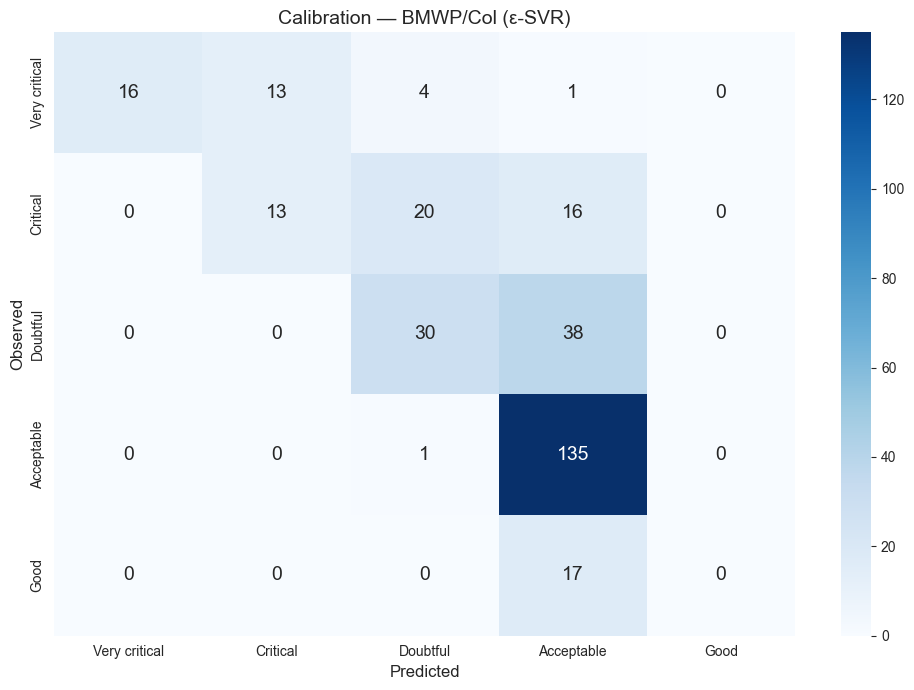

               precision    recall  f1-score   support

Very critical       1.00      0.47      0.64        34
     Critical       0.50      0.27      0.35        49
     Doubtful       0.55      0.44      0.49        68
   Acceptable       0.65      0.99      0.79       136
         Good       0.00      0.00      0.00        17

     accuracy                           0.64       304
    macro avg       0.54      0.43      0.45       304
 weighted avg       0.61      0.64      0.59       304

Cohen's Kappa (calibration): 0.430
Calibration numerical: MAE = 15.35, RMSE = 22.80, R² = 0.465, rs = 0.675
Note: calibration reflects near-in-sample performance; Section 10 (validation) is the primary evidence.


In [19]:
# Calibration confusion matrix and metrics (near-in-sample performance)
cal_true_class, cal_pred_class = to_classes(y_true_cal, y_pred_cal_crisp)
plot_confusion(cal_true_class, cal_pred_class, 'Calibration — BMWP/Col (ε-SVR)',
               'svr_bmwp_confusion_matrix_calibration.png')
print(classification_report(cal_true_class, cal_pred_class, labels=labels, zero_division=0))
print(f"Cohen's Kappa (calibration): {cohen_kappa_score(cal_true_class, cal_pred_class):.3f}")

cal_obs = np.array(y_true_cal); cal_hat = np.array(y_pred_cal_crisp)
print(f"Calibration numerical: MAE = {mean_absolute_error(cal_obs, cal_hat):.2f}, "
      f"RMSE = {np.sqrt(np.mean((cal_obs - cal_hat) ** 2)):.2f}, "
      f"R² = {r2_score(cal_obs, cal_hat):.3f}, "
      f"rs = {spearmanr(cal_obs, cal_hat)[0]:.3f}")
print("Note: calibration reflects near-in-sample performance; "
      "Section 10 (validation) is the primary evidence.")

## 10. Validation (Nested LOOCV)

The honest out-of-sample estimate: each metric below is computed on the held-out
stations only, where predictor selection, hyperparameter tuning and model fitting all
excluded that station.

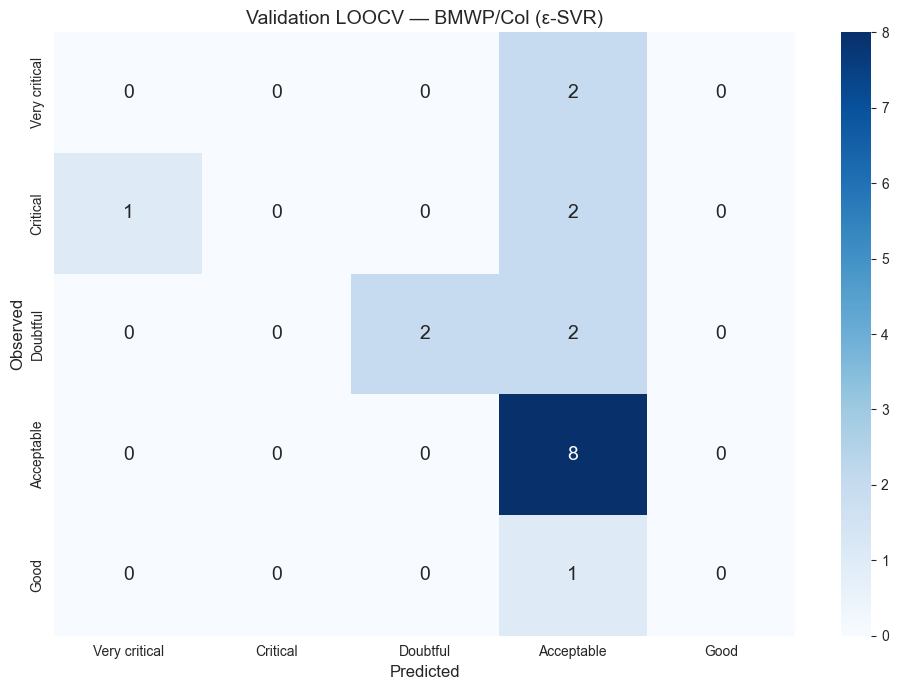

               precision    recall  f1-score   support

Very critical       0.00      0.00      0.00         2
     Critical       0.00      0.00      0.00         3
     Doubtful       1.00      0.50      0.67         4
   Acceptable       0.53      1.00      0.70         8
         Good       0.00      0.00      0.00         1

     accuracy                           0.56        18
    macro avg       0.31      0.30      0.27        18
 weighted avg       0.46      0.56      0.46        18

Cohen's Kappa (validation): 0.258


In [20]:
# Validation: map held-out predictions to classes, confusion matrix, classification report, kappa
val_true_class, val_pred_class = to_classes(y_true_val, y_pred_val_crisp)
plot_confusion(val_true_class, val_pred_class, 'Validation LOOCV — BMWP/Col (ε-SVR)',
               'svr_bmwp_confusion_matrix_validation.png')
print(classification_report(val_true_class, val_pred_class, labels=labels, zero_division=0))
kappa_svr = cohen_kappa_score(val_true_class, val_pred_class)
print(f"Cohen's Kappa (validation): {kappa_svr:.3f}")

In [21]:
# Regression metrics on the continuous held-out predictions
val_obs = np.array(y_true_val, dtype=float)
val_hat = np.array(y_pred_val_crisp, dtype=float)
mae_svr = mean_absolute_error(val_obs, val_hat)
rmse_svr = float(np.sqrt(np.mean((val_obs - val_hat) ** 2)))
r2_svr = r2_score(val_obs, val_hat)
rs_svr, p_svr = spearmanr(val_obs, val_hat)
print(f"MAE:  {mae_svr:.2f} BMWP points")
print(f"RMSE: {rmse_svr:.2f} BMWP points")
print(f"R²:   {r2_svr:.3f}")
print(f"Spearman rs: {rs_svr:.3f} (p = {p_svr:.4f})")

MAE:  23.71 BMWP points
RMSE: 31.60 BMWP points
R²:   -0.028
Spearman rs: 0.430 (p = 0.0746)


## 11. Predictor Stability

The per-fold predictor selection table and frequency counts below show which
physicochemical variables are most consistently informative across the 18 LOOCV
training partitions under AIC proxy selection. `Dureza` (total hardness) was selected
in 14 of 18 folds, consistent with the NBR results. The Spearman-based selection
(Section 8) yielded a different pattern — `Turbiedad` appeared in all 18 folds —
confirming that the two criteria do not agree on the most informative predictor for
BMWP.

In [22]:
# Model diagnostics: predictor stability and best hyperparameters per fold
stab = pd.DataFrame({'Fold': range(1, len(selected_predictors_per_fold) + 1),
                     'Selected predictors': ['+'.join(s) for s in selected_predictors_per_fold],
                     'C': [bp['svr__C'] for bp in best_params_per_fold],
                     'epsilon': [bp['svr__epsilon'] for bp in best_params_per_fold],
                     'gamma': [bp['svr__gamma'] for bp in best_params_per_fold]})
display(stab)

# Predictor selection frequency across folds
pred_freq = Counter(p for s in selected_predictors_per_fold for p in s)
pred_freq = {p: pred_freq.get(p, 0) for p in candidate_predictors}
modal_set = Counter(tuple(sorted(s)) for s in selected_predictors_per_fold).most_common(1)[0]
print("Predictor selection frequency (folds containing each predictor):", pred_freq)
print(f"Modal predictor set: {modal_set[0]} selected in {modal_set[1]}/{len(selected_predictors_per_fold)} folds")

# Most common hyperparameter combination
hp_counts = Counter((bp['svr__C'], bp['svr__epsilon'], bp['svr__gamma']) for bp in best_params_per_fold)
print("Most common (C, epsilon, gamma) combinations:", hp_counts.most_common(3))

# Persist fold-level diagnostics
stab.to_csv("../../outputs/svr_bmwp_fold_details.csv", index=False)
print("Saved outputs/svr_bmwp_fold_details.csv")

,Fold,Selected predictors,C,epsilon,gamma
0,1,Dureza,100,1.0,scale
1,2,Dureza,100,1.0,scale
2,3,Turbiedad,10,2.0,scale
3,4,Dureza,100,1.0,scale
4,5,Dureza,100,2.0,auto
5,6,Dureza,100,1.0,scale
6,7,Dureza,100,2.0,scale
7,8,Dureza,100,1.0,scale
8,9,Dureza,100,1.0,scale
9,10,Magnesio,100,0.1,scale


Predictor selection frequency (folds containing each predictor): {'COT': 0, 'DBO5': 0, 'Dureza': 14, 'Magnesio': 1, 'Turbiedad': 3, 'OD': 0, 'Caudal': 0}
Modal predictor set: ('Dureza',) selected in 14/18 folds
Most common (C, epsilon, gamma) combinations: [((100, 1.0, 'scale'), 8), ((100, 0.1, 'scale'), 3), ((10, 2.0, 'scale'), 2)]
Saved outputs/svr_bmwp_fold_details.csv


## Numerical Performance Summary

In [23]:
# Numerical performance summary and comparison with the other BMWP models (nested LOOCV)
print(f"=== SVR BMWP Numerical Performance (Nested LOOCV, n={len(val_obs)}) ===")
print(f"MAE:  {mae_svr:.2f} BMWP points")
print(f"RMSE: {rmse_svr:.2f} BMWP points")
print(f"R²:   {r2_svr:.3f}")
print(f"Spearman rs: {rs_svr:.3f} (p = {p_svr:.4f})")
print(f"Cohen's Kappa: {kappa_svr:.3f}")
print()
print(f"Interpretation: on average, the SVR model's BMWP predictions deviate")
print(f"by {mae_svr:.2f} points from the observed values on the BMWP/Col scale (0-120).")
print()

# Reference values (nested LOOCV) from the fuzzy redesigned and NBR notebooks
fuzzy_mae, fuzzy_r2, fuzzy_rs, fuzzy_kappa = 26.77, 0.07, 0.281, 0.163
nbr_mae, nbr_r2, nbr_rs, nbr_kappa = 31.95, -0.27, -0.162, 0.000

def verdict(svr, fuzzy, nbr, higher_is_better=True):
    if higher_is_better:
        best = max(svr, fuzzy, nbr)
    else:
        best = min(svr, fuzzy, nbr)
    return "outperforms" if svr == best else ("matches" if abs(svr - best) < 1e-9 else "underperforms")

print(f"Compared with fuzzy logic redesigned (nested: MAE={fuzzy_mae}, R²={fuzzy_r2}, kappa={fuzzy_kappa})")
print(f"and negative binomial regression (nested: MAE={nbr_mae}, R²={nbr_r2}, kappa={nbr_kappa}):")
print(f"  - MAE: SVR {verdict(mae_svr, fuzzy_mae, nbr_mae, higher_is_better=False)} (lower is better)")
print(f"  - R²:  SVR {verdict(r2_svr, fuzzy_r2, nbr_r2)}")
print(f"  - Spearman rs: SVR {verdict(rs_svr, fuzzy_rs, nbr_rs)}")
print(f"  - Kappa: SVR {verdict(kappa_svr, fuzzy_kappa, nbr_kappa)}")

# Export class-level and numerical metrics for the master results table
present = [c for c in labels if c in val_true_class]
prec, rec, f1m, _ = precision_recall_fscore_support(val_true_class, val_pred_class, labels=present,
                                                    average='macro', zero_division=0)
acc_svr = accuracy_score(val_true_class, val_pred_class)
pd.DataFrame([{'target': 'BMWP', 'technique': 'ε-SVR', 'validation': 'Nested LOOCV', 'n': len(val_obs),
               'precision': round(prec, 3), 'recall': round(rec, 3), 'f1': round(f1m, 3),
               'accuracy': round(acc_svr, 3), 'kappa': round(kappa_svr, 3),
               'modal_predictors': '+'.join(modal_set[0]),
               'predictor_stability': f"{modal_set[1]}/{len(selected_predictors_per_fold)}"}]
             ).to_csv("../../outputs/metrics_svr_bmwp.csv", index=False)
pd.DataFrame([{'model': 'ε-SVR', 'validation': 'Nested LOOCV', 'n': len(val_obs),
               'mae': round(mae_svr, 2), 'rmse': round(rmse_svr, 2), 'r2': round(r2_svr, 3),
               'rs': round(rs_svr, 3), 'p_value': round(p_svr, 4)}]
             ).to_csv("../../outputs/numerical_bmwp_svr.csv", index=False)
print()
print("Saved outputs/metrics_svr_bmwp.csv and outputs/numerical_bmwp_svr.csv")

=== SVR BMWP Numerical Performance (Nested LOOCV, n=18) ===
MAE:  23.71 BMWP points
RMSE: 31.60 BMWP points
R²:   -0.028
Spearman rs: 0.430 (p = 0.0746)
Cohen's Kappa: 0.258

Interpretation: on average, the SVR model's BMWP predictions deviate
by 23.71 points from the observed values on the BMWP/Col scale (0-120).

Compared with fuzzy logic redesigned (nested: MAE=26.77, R²=0.07, kappa=0.163)
and negative binomial regression (nested: MAE=31.95, R²=-0.27, kappa=0.0):
  - MAE: SVR outperforms (lower is better)
  - R²:  SVR underperforms
  - Spearman rs: SVR outperforms
  - Kappa: SVR outperforms

Saved outputs/metrics_svr_bmwp.csv and outputs/numerical_bmwp_svr.csv


## Visualisation

Three diagnostics are produced and saved to `outputs/`: observed vs predicted BMWP,
predictor selection frequency across folds, and the distribution of tuned
hyperparameters across folds.

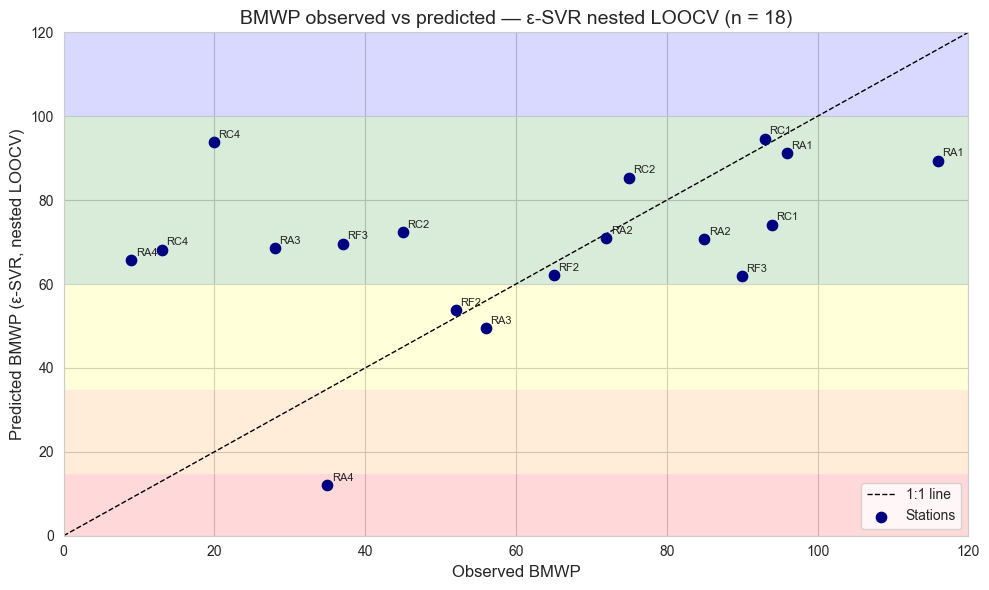

In [24]:
# Plot 1: observed vs predicted BMWP (nested LOOCV) with 1:1 line and quality-band backgrounds
stations = [df.iloc[i][station_col] for i in range(len(df))]
bands = [(0, 15, 'red'), (15, 35, 'darkorange'), (35, 60, 'yellow'),
         (60, 100, 'green'), (100, 120, 'blue')]
plt.figure(figsize=(10, 6))
for lo, hi, col in bands:
    plt.axhspan(lo, hi, facecolor=col, alpha=0.15)
plt.plot([0, 120], [0, 120], 'k--', linewidth=1, label='1:1 line')
plt.scatter(val_obs, val_hat, color='navy', s=55, zorder=3, label='Stations')
for x, y, lab in zip(val_obs, val_hat, stations):
    plt.annotate(str(lab), (x, y), fontsize=8, xytext=(3, 3), textcoords='offset points')
plt.xlim(0, 120); plt.ylim(0, 120)
plt.xlabel('Observed BMWP', fontsize=12)
plt.ylabel('Predicted BMWP (ε-SVR, nested LOOCV)', fontsize=12)
plt.title(f'BMWP observed vs predicted — ε-SVR nested LOOCV (n = {len(val_obs)})', fontsize=14)
plt.legend(loc='lower right')
plt.tight_layout(); plt.savefig("../../outputs/svr_bmwp_observed_vs_predicted.png", dpi=300); plt.show()

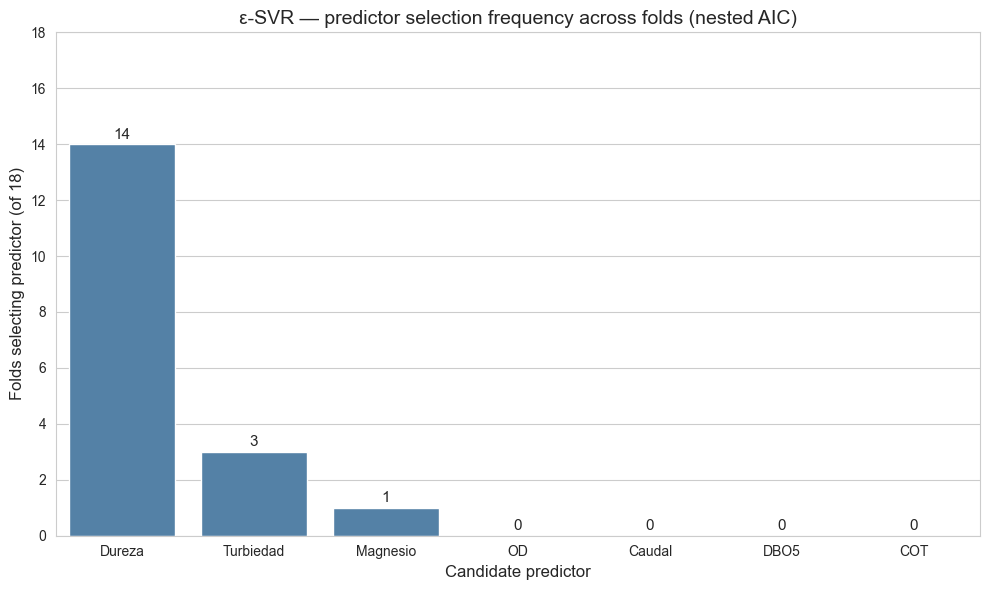

In [25]:
# Plot 2: predictor selection frequency across the 18 folds
plt.figure(figsize=(10, 6))
preds = list(pred_freq.keys()); freqs = [pred_freq[p] for p in preds]
order = np.argsort(freqs)[::-1]
preds = [preds[i] for i in order]; freqs = [freqs[i] for i in order]
sns.barplot(x=preds, y=freqs, color='steelblue')
plt.ylabel('Folds selecting predictor (of 18)', fontsize=12); plt.xlabel('Candidate predictor', fontsize=12)
plt.title('ε-SVR — predictor selection frequency across folds (nested AIC)', fontsize=14)
plt.ylim(0, 18)
for i, v in enumerate(freqs):
    plt.text(i, v + 0.2, str(v), ha='center', fontsize=11)
plt.tight_layout(); plt.savefig("../../outputs/svr_bmwp_predictor_frequency.png", dpi=300); plt.show()

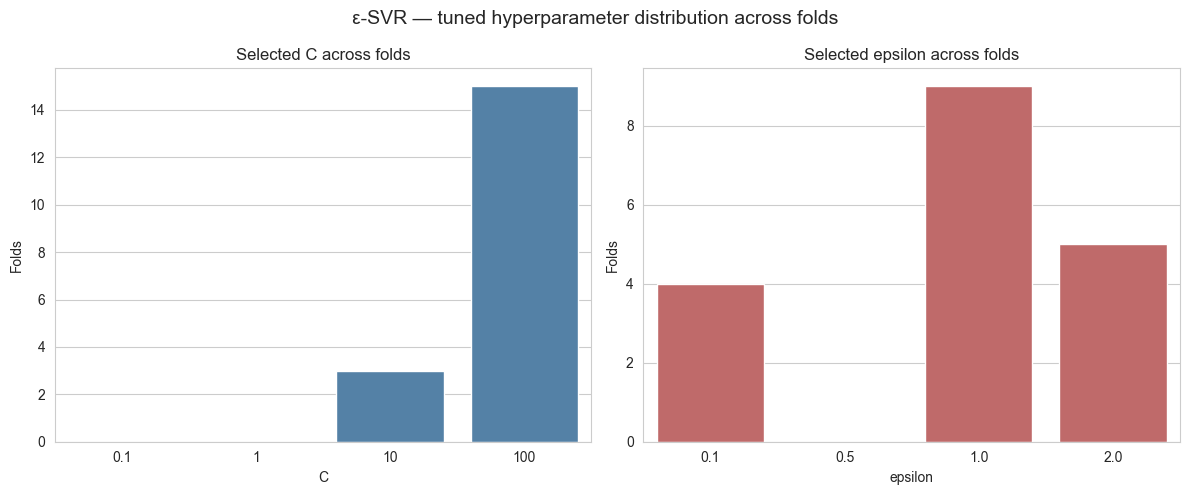

In [26]:
# Plot 3: distribution of tuned hyperparameters (C and epsilon) across folds
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
C_vals = [bp['svr__C'] for bp in best_params_per_fold]
eps_vals = [bp['svr__epsilon'] for bp in best_params_per_fold]
sns.countplot(x=[str(c) for c in C_vals], order=[str(c) for c in param_grid['svr__C']],
              color='steelblue', ax=axes[0])
axes[0].set_title('Selected C across folds'); axes[0].set_xlabel('C'); axes[0].set_ylabel('Folds')
sns.countplot(x=[str(e) for e in eps_vals], order=[str(e) for e in param_grid['svr__epsilon']],
              color='indianred', ax=axes[1])
axes[1].set_title('Selected epsilon across folds'); axes[1].set_xlabel('epsilon'); axes[1].set_ylabel('Folds')
fig.suptitle('ε-SVR — tuned hyperparameter distribution across folds', fontsize=14)
plt.tight_layout(); plt.savefig("../../outputs/svr_bmwp_hyperparameters.png", dpi=300); plt.show()

## 12. Limitations

- SVR requires hyperparameter tuning (C, epsilon, gamma); with n=17
  training observations per fold and inner LOOCV for tuning, the grid
  search uses n=16 for each inner fold — a very small training set that
  may produce unstable hyperparameter estimates.
- The RBF kernel implicitly assumes smooth, continuous relationships
  between predictors and BMWP; if the true relationship has sharp
  ecological thresholds, a linear kernel may be more appropriate.
- Predictor selection by AIC (NBR-based proxy) is an approximation: AIC
  is derived from likelihood theory and is not directly applicable to
  kernel methods. This limitation is documented in Section 4 and
  empirically evaluated in Section 8.
- With n=18 and 5 BMWP quality classes, some classes may have 0 or 1
  observations in certain training folds, which can cause classification
  metrics to be undefined or unstable.

In [27]:
# ── Cross-model final summary: AIC vs Spearman across SVR, NBR, and Logistic ──
# Requires outputs from all three sensitivity sections (run notebooks 02, 04, 05 first)
import os

_sensitivity_files = {
    'SVR':      "../../outputs/sensitivity_svr_aic_vs_spearman.csv",
    'NBR':      "../../outputs/sensitivity_nbr_aic_vs_spearman.csv",
    'Logistic': "../../outputs/sensitivity_logistic_aic_vs_spearman.csv",
}
_missing = [k for k, p in _sensitivity_files.items() if not os.path.exists(p)]
if _missing:
    print(f"[WARNING] Sensitivity CSVs not yet available for: {_missing}. "
          "Run notebooks 02 and 04 sensitivity sections first, then re-run this cell.")
else:
    _frames = [pd.read_csv(p) for p in _sensitivity_files.values()]
    summary_all = pd.concat(_frames, ignore_index=True)

    print("=" * 75)
    print("  Cross-model sensitivity: AIC vs Spearman predictor selection")
    print("  (Nested LOOCV, n = 18 stations, Cali River)")
    print("=" * 75)

    # ── Regression models (SVR, NBR) ───────────────────────────────────────────
    reg = summary_all[summary_all['mae'].notna()].copy()
    if not reg.empty:
        print("\nRegression metrics (MAE / RMSE / R² / Spearman rs):")
        display(reg[['model', 'target', 'selection_criterion',
                      'mae', 'rmse', 'r2', 'spearman_rs',
                      'kappa', 'modal_predictors', 'predictor_stability']
                    ].rename(columns={'selection_criterion': 'criterion',
                                      'spearman_rs': 'rs',
                                      'modal_predictors': 'modal',
                                      'predictor_stability': 'stability'})
                  .reset_index(drop=True))

    # ── Classification models (Logistic) ──────────────────────────────────────
    cls = summary_all[summary_all['mae'].isna()].copy()
    if not cls.empty:
        print("\nClassification metrics (accuracy / κ):")
        display(cls[['model', 'target', 'selection_criterion',
                      'accuracy', 'kappa',
                      'modal_predictors', 'predictor_stability']
                    ].rename(columns={'selection_criterion': 'criterion',
                                      'modal_predictors': 'modal',
                                      'predictor_stability': 'stability'})
                  .reset_index(drop=True))

    # ── Decision guidance ──────────────────────────────────────────────────────
    print("\nDecision guidance:")
    print("  • A criterion that consistently improves (or matches) metrics across")
    print("    all three models and both targets should be standardised.")
    print("  • If Spearman reduces MAE/RMSE for SVR and NBR AND maintains or")
    print("    improves κ for Logistic, prefer Spearman (simpler, model-agnostic).")
    print("  • If AIC wins or ties on ≥2 models, retain AIC for BMWP models")
    print("    and consider Spearman only where it clearly wins.")


  Cross-model sensitivity: AIC vs Spearman predictor selection
  (Nested LOOCV, n = 18 stations, Cali River)

Regression metrics (MAE / RMSE / R² / Spearman rs):


,model,target,criterion,mae,rmse,r2,rs,kappa,modal,stability
0,ε-SVR,BMWP,AIC,23.71,31.60,-0.028,0.430,0.258,Dureza,14/18
1,ε-SVR,BMWP,Spearman,29.75,33.14,-0.131,0.086,0.130,DBO5+Dureza+Turbiedad,12/18
2,NBR,BMWP,AIC,31.95,35.13,-0.270,-0.162,0.000,Dureza,14/18
3,NBR,BMWP,Spearman,30.75,33.54,-0.158,0.191,-0.011,Turbiedad+DBO5+Dureza,8/18



Classification metrics (accuracy / κ):


,model,target,criterion,accuracy,kappa,modal,stability
0,Logistic,Perlidae,AIC,0.556,0.200,DBO5,16/18
1,Logistic,Perlidae,Spearman,0.611,0.276,DBO5+Dureza,16/18
2,Logistic,Helicopsychidae,AIC,0.611,0.276,Caudal,10/18
3,Logistic,Helicopsychidae,Spearman,0.667,0.217,Caudal+DBO5,17/18



Decision guidance:
  • A criterion that consistently improves (or matches) metrics across
    all three models and both targets should be standardised.
  • If Spearman reduces MAE/RMSE for SVR and NBR AND maintains or
    improves κ for Logistic, prefer Spearman (simpler, model-agnostic).
  • If AIC wins or ties on ≥2 models, retain AIC for BMWP models
    and consider Spearman only where it clearly wins.
